In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [2]:
df=pd.read_csv('/kaggle/input/diabetes021/diabetes - diabetes.csv')

In [3]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [5]:
df.duplicated().sum()

0

In [6]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


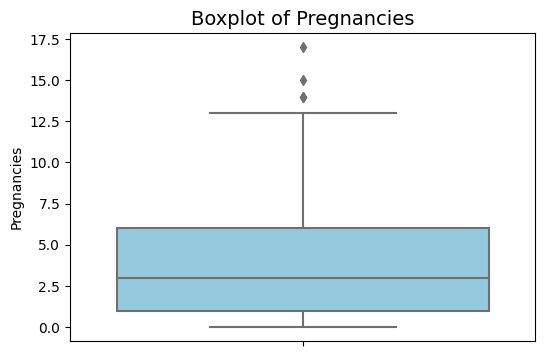

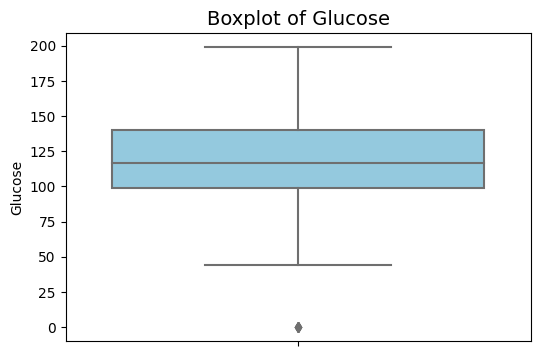

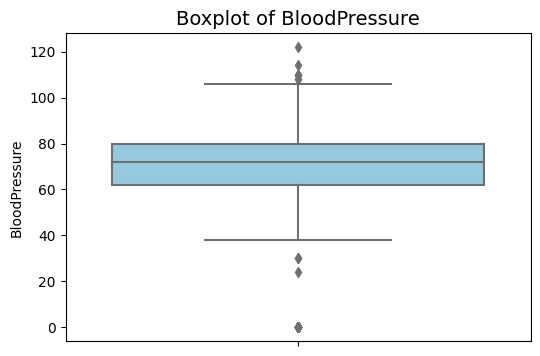

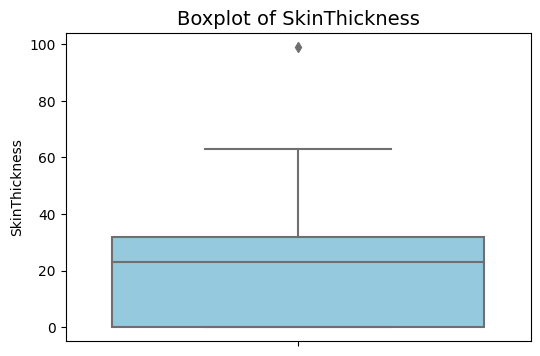

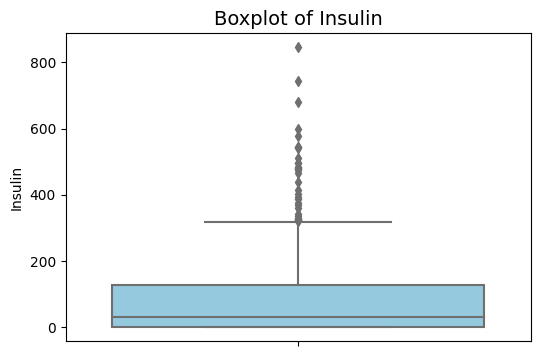

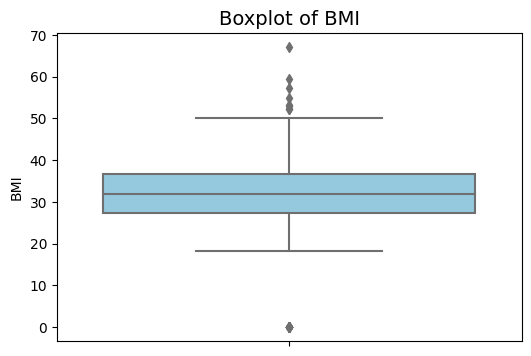

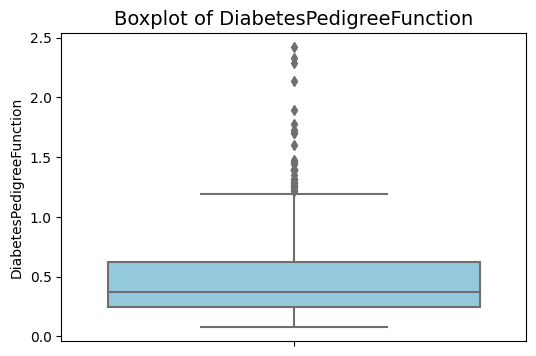

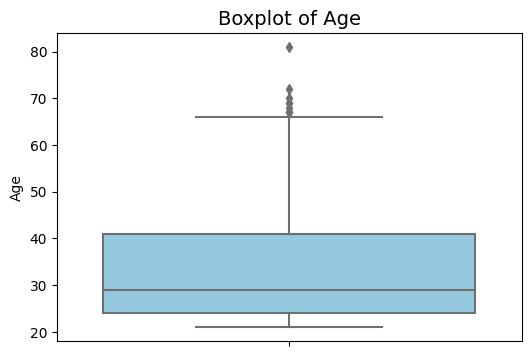

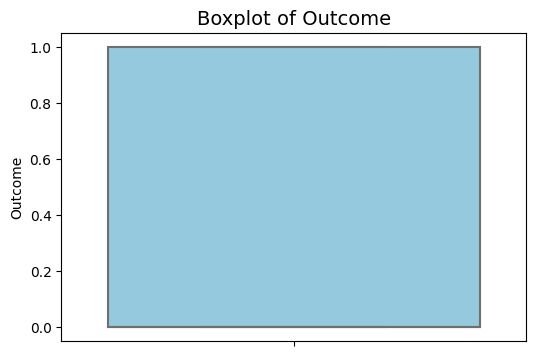

In [7]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(y=df[col], color="skyblue")
    plt.title(f"Boxplot of {col}", fontsize=14)
    plt.ylabel(col)
    plt.show()

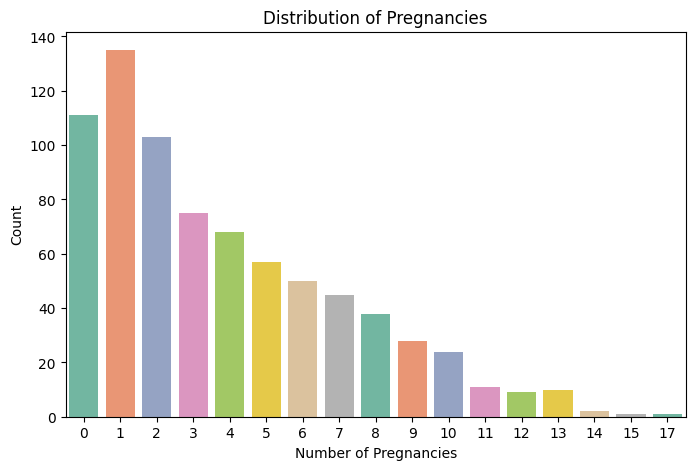

In [8]:
plt.figure(figsize=(8,5))
sns.countplot(x=df["Pregnancies"], palette="Set2")
plt.title("Distribution of Pregnancies")
plt.xlabel("Number of Pregnancies")
plt.ylabel("Count")
plt.show()

<div style="border-radius:10px; border:#808080 solid; padding: 15px; background-color:##F0E68C ; font-size:100%; text-align:left">

### 📊 Pregnancies Distribution
This chart shows the **number of times women in the dataset have been pregnant**.  
- Most women had between **0 and 6 pregnancies**.  
- Higher values (such as 10 or more pregnancies) are very rare.  
- This means that the majority of women in the study had either no pregnancies or just a few.


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


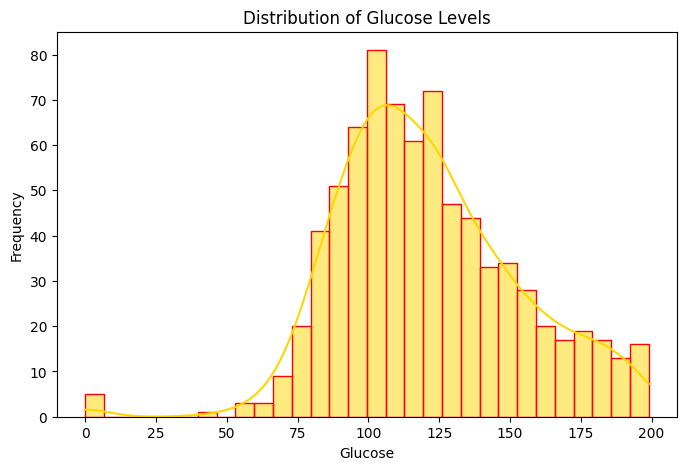

In [9]:
plt.figure(figsize=(8,5))
sns.histplot(df["Glucose"], bins=30, kde=True, color="gold",edgecolor='red')
plt.title("Distribution of Glucose Levels")
plt.xlabel("Glucose")
plt.ylabel("Frequency")
plt.show()

<div style="border-radius:10px; border:#808080 solid; padding: 15px; background-color:##F0E68C ; font-size:100%; text-align:left">

### 📊 Glucose Levels Distribution
This chart shows the **blood glucose levels** of the patients.  
- Most values fall between **90 and 150**.  
- Some cases reached as high as **around 200**.  
- Originally, there were zeros in this column, but medically a glucose level of zero is not possible. These were treated as missing values and corrected.  
- In general, **higher glucose levels strongly increase the chance of having diabetes**.

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


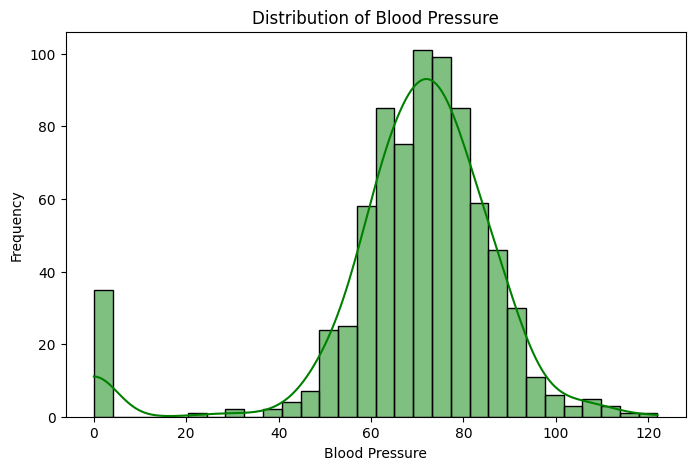

In [10]:
plt.figure(figsize=(8,5))
sns.histplot(df["BloodPressure"], bins=30, kde=True, color="green")
plt.title("Distribution of Blood Pressure")
plt.xlabel("Blood Pressure")
plt.ylabel("Frequency")
plt.show()

<div style="border-radius:10px; border:#808080 solid; padding: 15px; background-color:##F0E68C ; font-size:100%; text-align:left">

### 📊 Blood Pressure Distribution
This chart shows the **blood pressure (mmHg)** of the patients.  
- The average blood pressure is around **70–80 mmHg**, which is considered normal.  
- Some patients have very low values (close to zero), which are not realistic and were corrected.  
- Most people in the dataset fall within the normal blood pressure range, but a few outliers have unusually high or low values.


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


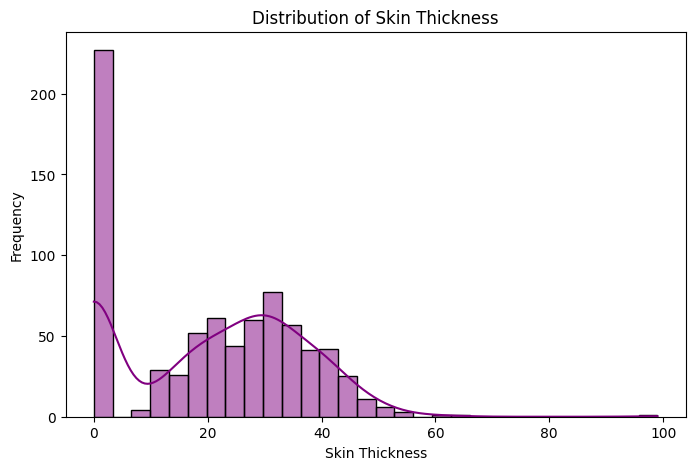

In [11]:
plt.figure(figsize=(8,5))
sns.histplot(df["SkinThickness"], bins=30, kde=True, color="purple")
plt.title("Distribution of Skin Thickness")
plt.xlabel("Skin Thickness")
plt.ylabel("Frequency")
plt.show()

<div style="border-radius:10px; border:#808080 solid; padding: 15px; background-color:##F0E68C ; font-size:100%; text-align:left">

### 📊 Skin Thickness Distribution
This chart represents the **skinfold thickness measurement (in mm)**, which is related to body fat.  
- Many patients have values between **15 and 40 mm**.  
- Some entries had a value of zero, which is not possible in real life and was corrected.  
- A few patients have very high values (close to 100 mm), which are rare outliers.  
- Overall, most patients have normal thickness values that indicate an average level of body fat.


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


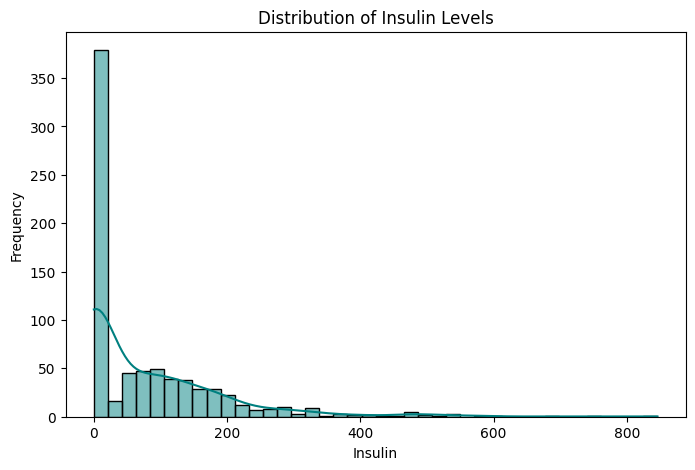

In [12]:
plt.figure(figsize=(8,5))
sns.histplot(df["Insulin"], bins=40, kde=True, color="teal")
plt.title("Distribution of Insulin Levels")
plt.xlabel("Insulin")
plt.ylabel("Frequency")
plt.show()

<div style="border-radius:10px; border:#808080 solid; padding: 15px; background-color:##F0E68C ; font-size:100%; text-align:left">

### 📊 Insulin Levels Distribution
This chart shows the **blood insulin levels** of the patients.  
- The distribution is very spread out and skewed.  
- Many patients had very low insulin values, while a few had extremely high levels (up to **846**).  
- Zero values originally appeared, but those are not realistic and were treated as missing.  
- Because of the wide range, insulin is a tricky variable with many outliers.


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


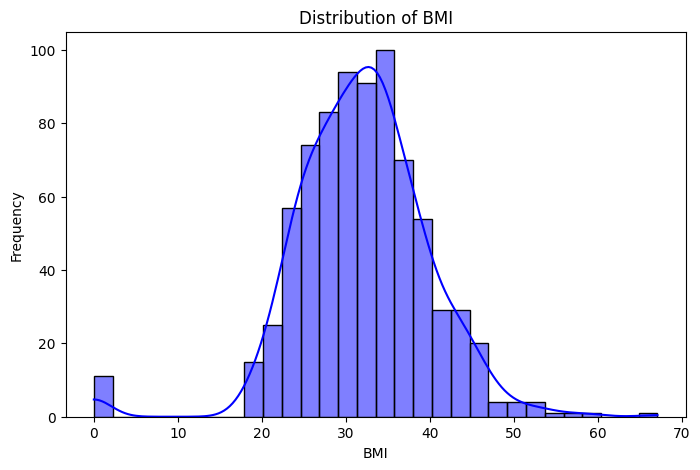

In [13]:
plt.figure(figsize=(8,5))
sns.histplot(df["BMI"], bins=30, kde=True, color="blue")
plt.title("Distribution of BMI")
plt.xlabel("BMI")
plt.ylabel("Frequency")
plt.show()

<div style="border-radius:10px; border:#808080 solid; padding: 15px; background-color:##F0E68C ; font-size:100%; text-align:left">

### 📊 BMI (Body Mass Index) Distribution
This chart shows the **Body Mass Index (BMI)** of patients.  
- Most patients fall between **25 and 35**, which indicates **overweight to obese ranges**.  
- Very few patients have values above 40 (severe obesity).  
- Some zero values existed originally, which are not possible, and were corrected.  
- This confirms that many patients in this study are overweight, which is a known risk factor for diabetes.


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


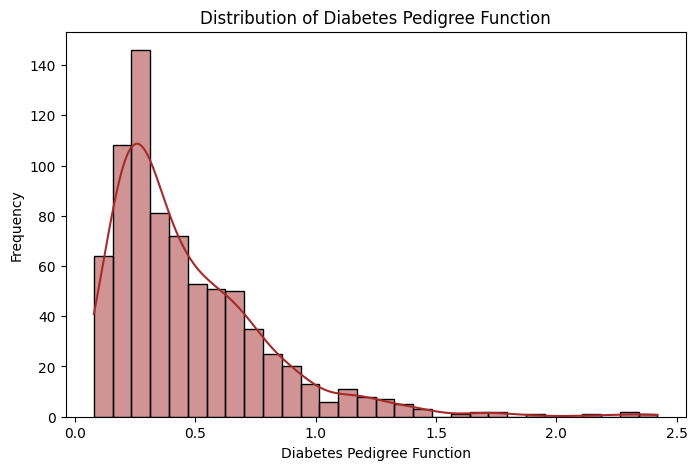

In [14]:
plt.figure(figsize=(8,5))
sns.histplot(df["DiabetesPedigreeFunction"], bins=30, kde=True, color="brown")
plt.title("Distribution of Diabetes Pedigree Function")
plt.xlabel("Diabetes Pedigree Function")
plt.ylabel("Frequency")
plt.show()

<div style="border-radius:10px; border:#808080 solid; padding: 15px; background-color:##F0E68C ; font-size:100%; text-align:left">

### 📊 Diabetes Pedigree Function Distribution
This chart shows the **Diabetes Pedigree Function (DPF)**, which measures genetic risk based on family history.  
- Most patients have values between **0.2 and 0.6**.  
- A few cases reach up to **2.4**, which are rare but indicate very strong family-related risk.  
- The distribution is skewed, meaning that a small group of patients have unusually high genetic risk compared to the majority.


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


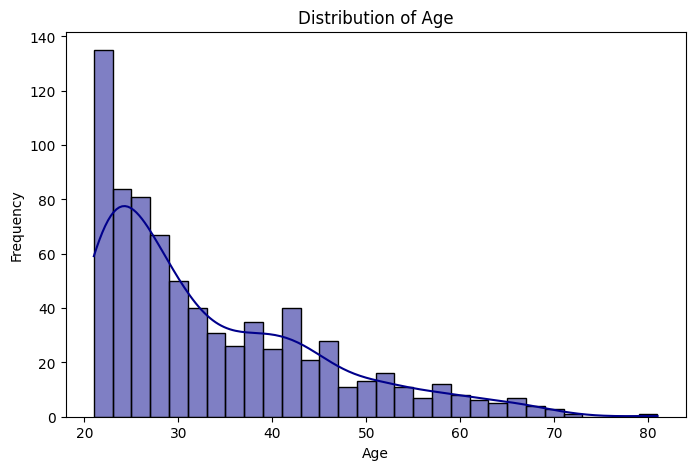

In [15]:
plt.figure(figsize=(8,5))
sns.histplot(df["Age"], bins=30, kde=True, color="darkblue")
plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

<div style="border-radius:10px; border:#808080 solid; padding: 15px; background-color:##F0E68C ; font-size:100%; text-align:left">

### 📊 Age Distribution
This chart shows the **ages of patients** in the dataset.  
- Most patients are between **20 and 40 years old**.  
- Some older patients are included, with the maximum age being **81**.  
- The number of patients decreases gradually as age increases.  
- Since diabetes risk rises with age, this distribution shows that most patients studied are younger adults, but older high-risk groups are also represented.


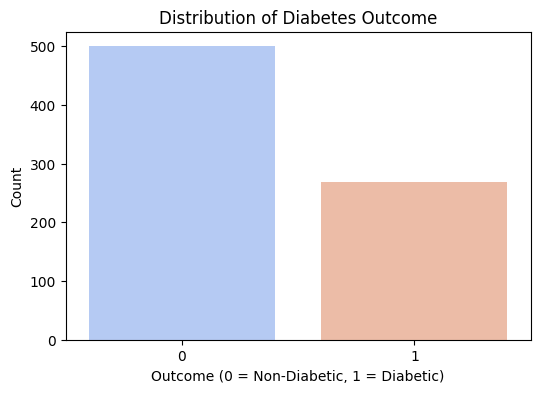

In [16]:
plt.figure(figsize=(6,4))
sns.countplot(x=df["Outcome"], palette="coolwarm")
plt.title("Distribution of Diabetes Outcome")
plt.xlabel("Outcome (0 = Non-Diabetic, 1 = Diabetic)")
plt.ylabel("Count")
plt.show()

<div style="border-radius:10px; border:#808080 solid; padding: 15px; background-color:##F0E68C ; font-size:100%; text-align:left">

### 📊 Diabetes Outcome Distribution
This chart shows the **number of patients diagnosed with diabetes (1) vs. those not diagnosed (0)**.  
- **500 patients** (about 65%) do **not have diabetes**.  
- **268 patients** (about 35%) **have diabetes**.  
- This imbalance is important for machine learning, as the dataset contains more non-diabetic than diabetic cases.


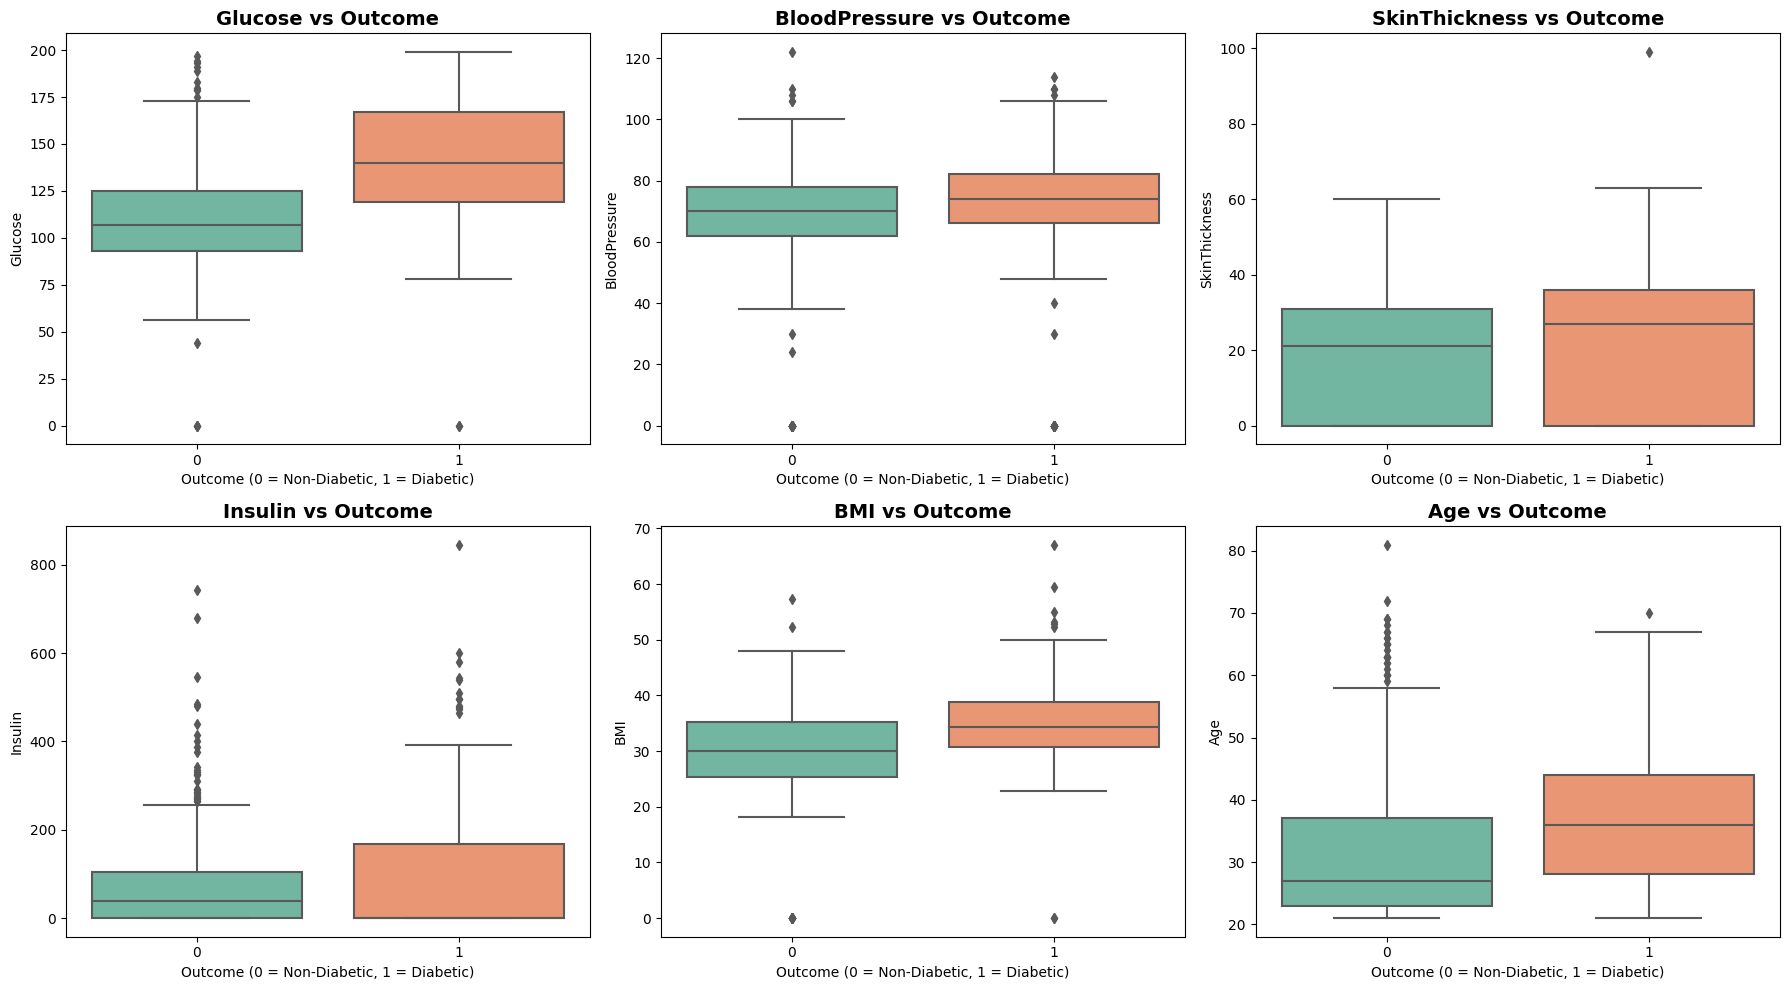

In [17]:
features = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI", "Age"]

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.boxplot(x="Outcome", y=col, data=df, palette="Set2", ax=axes[i])
    axes[i].set_title(f"{col} vs Outcome", fontsize=14, fontweight="bold")
    axes[i].set_xlabel("Outcome (0 = Non-Diabetic, 1 = Diabetic)", fontsize=10)
    axes[i].set_ylabel(col, fontsize=10)

plt.tight_layout()
plt.show()

<div style="border-radius:10px; border:#808080 solid; padding: 15px; background-color:##F0E68C ; font-size:100%; text-align:left">

### 📊 Glucose vs Outcome
This chart compares **blood glucose levels** between people with and without diabetes.  

- People **without diabetes (Outcome = 0)** mostly have glucose levels in the **90–130 range**, which is considered closer to normal.  
- People **with diabetes (Outcome = 1)** show much higher glucose levels, often **above 140** and sometimes close to **200**.  
- The boxplot shows a clear separation: **higher glucose strongly correlates with diabetes**.  
This confirms that glucose is one of the most important indicators for diagnosing diabetes.

### 📊 Blood Pressure vs Outcome
This chart shows **blood pressure levels** for both groups.  

- Both non-diabetic and diabetic individuals have blood pressure mostly around **70–85 mmHg**.  
- There isn’t a strong visible difference between the two groups.  
- Some extreme low values exist (below 50), which may be due to incorrect measurements or rare cases.  

👉 Conclusion: Blood pressure alone does not strongly separate diabetic from non-diabetic individuals in this dataset.

### 📊 Skin Thickness vs Outcome
This chart illustrates **skinfold thickness** (a measure of body fat).  

- Most values are between **15 and 40 mm**, for both groups.  
- Diabetic individuals show slightly higher values on average, but the difference is not very strong.  
- The wide spread of data suggests variability, and many outliers exist.  

👉 Conclusion: Skin thickness may have some impact, but it is **not a strong standalone predictor** of diabetes.

### 📊 Insulin vs Outcome
This chart shows **insulin levels in the blood**.  

- Both groups show a very wide range, from very low to over **500 units**.  
- Many individuals (both diabetic and non-diabetic) have very low insulin levels close to zero, which may not be realistic in medical terms and could represent missing or incorrect data.  
- While some diabetics do have higher insulin levels, the overlap between the two groups is significant.  

👉 Conclusion: Insulin has potential importance, but because of data quality issues (many zeros and outliers), it is **not reliable by itself** in this dataset.

### 📊 BMI vs Outcome
This chart compares **Body Mass Index (BMI)** between the two groups.  

- Non-diabetic individuals mostly fall within a **BMI of 25–32**.  
- Diabetic individuals generally have a **higher BMI, often above 30**, which falls into the overweight/obese category.  
- The boxplot shows a clear upward shift for diabetics.  

👉 Conclusion: Higher BMI is associated with a greater risk of diabetes, making it an important predictive factor.

### 📊 Age vs Outcome
This chart shows how **age** relates to diabetes.  

- Non-diabetic individuals are often **younger**, with most between **20 and 35 years old**.  
- Diabetic individuals are generally **older**, many in their **40s and above**.  
- The median age is clearly higher for diabetics.  

👉 Conclusion: Age is a strong risk factor, with diabetes being more common among older individuals.


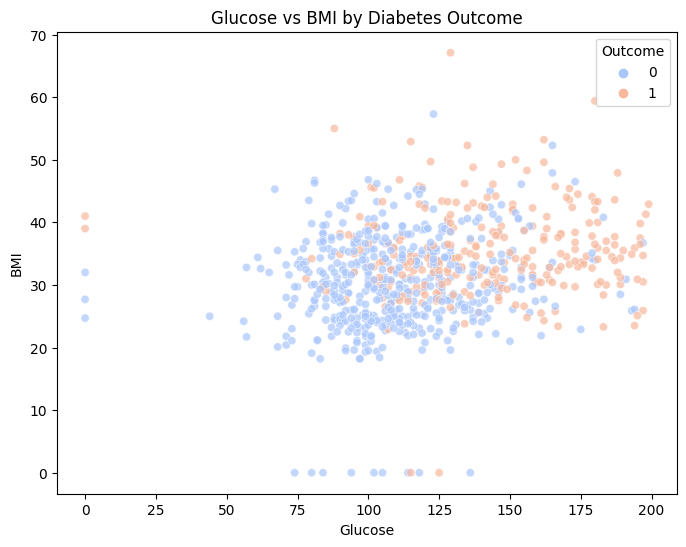

In [18]:
plt.figure(figsize=(8,6))
sns.scatterplot(x="Glucose", y="BMI", hue="Outcome", data=df, alpha=0.7, palette="coolwarm")
plt.title("Glucose vs BMI by Diabetes Outcome")
plt.xlabel("Glucose")
plt.ylabel("BMI")
plt.show()


<div style="border-radius:10px; border:#808080 solid; padding: 15px; background-color:##F0E68C ; font-size:100%; text-align:left">

### 📊 Scatterplots: Glucose & BMI vs Outcome
These scatterplots help us see the relationship between **Glucose, BMI, and Diabetes Outcome**.

- **Glucose vs Outcome**:  
  - Non-diabetic individuals (Outcome = 0) usually have glucose levels below **140**.  
  - Diabetic individuals (Outcome = 1) often show much higher glucose, with many points above **150**.  
  - This confirms glucose is a key factor in predicting diabetes.  

- **BMI vs Outcome**:  
  - Non-diabetics are concentrated at **BMI values between 20–30**.  
  - Diabetics tend to have higher BMI, often **above 30 (obese range)**.  
  - The scatter shows a clear trend: **higher BMI is linked to a higher chance of diabetes**.  

👉 Together, these plots show how **weight (BMI)** and **blood sugar (Glucose)** are strong risk factors for diabetes.


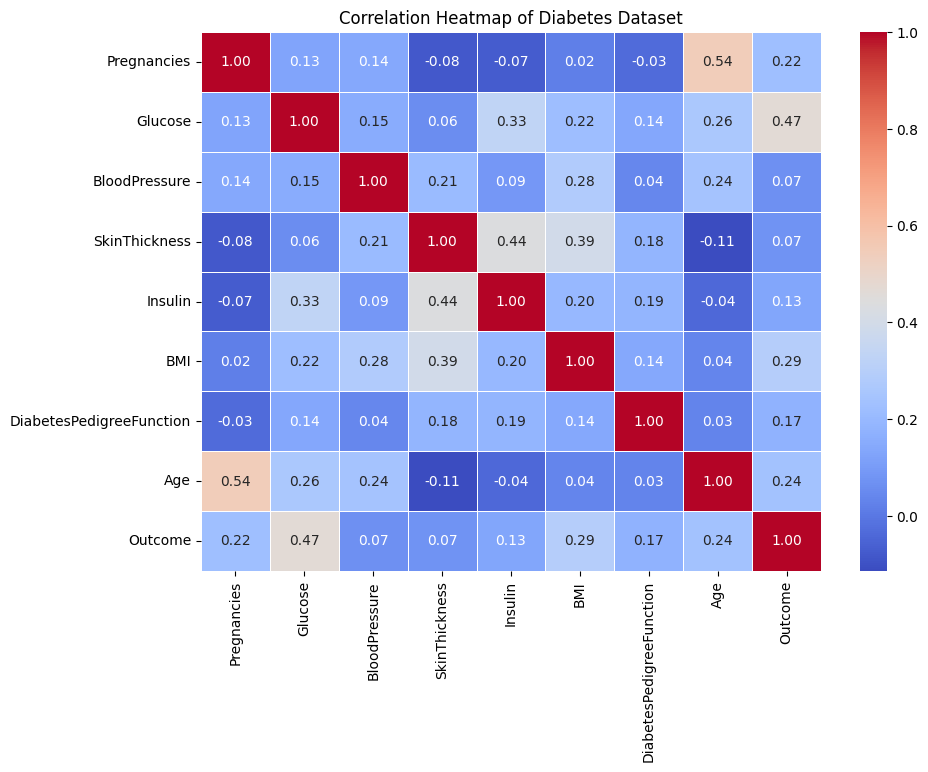

In [19]:
plt.figure(figsize=(10,7))
corr = df.corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Diabetes Dataset")
plt.show()


<div style="border-radius:10px; border:#808080 solid; padding: 15px; background-color:##F0E68C ; font-size:100%; text-align:left">

### 📊 Correlation Heatmap
This heatmap shows the **correlation between all features** in the dataset.  
Correlation values range from **-1 (strong negative)** to **+1 (strong positive)**.

Key insights:
- **Glucose** has the strongest positive correlation with the diabetes outcome (~0.47).  
- **BMI** and **Age** also show a moderate positive correlation with diabetes.  
- Some features, like **Blood Pressure** and **Skin Thickness**, have weak correlations with outcome.  
- There are also relationships between features themselves (e.g., BMI and Skin Thickness).  

👉 The heatmap makes it clear that **Glucose, BMI, and Age are the most important features** for predicting diabetes in this dataset.


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated a

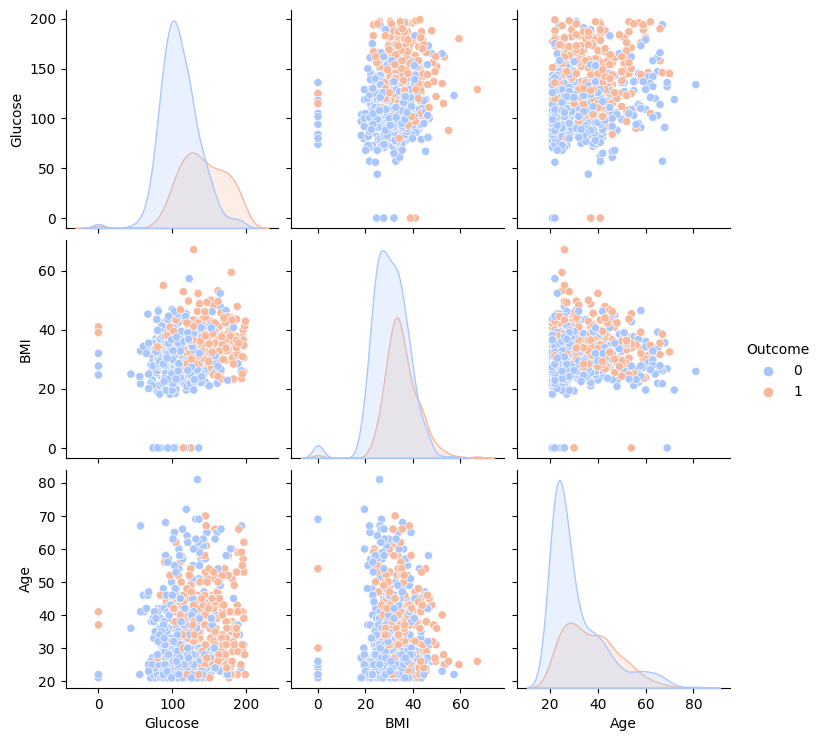

In [20]:
sns.pairplot(df[["Glucose", "BMI", "Age", "Outcome"]], hue="Outcome", palette="coolwarm")
plt.show()


<div style="border-radius:10px; border:#808080 solid; padding: 15px; background-color:##F0E68C ; font-size:100%; text-align:left">

### 📊 Pairplot for Selected Features
The pairplot gives a **multi-dimensional view** of the relationships between selected features:  
(Glucose, BMI, Age, and Outcome).

- It shows **scatterplots for feature pairs** and **distributions along the diagonal**.  
- For Glucose and BMI, the diabetic group clearly clusters at higher values.  
- Age adds another dimension: most diabetics are **older with higher glucose and BMI**.  
- Non-diabetics are more spread out at lower values across all features.  

👉 The pairplot highlights how a **combination of features (Glucose + BMI + Age)** provides a much stronger signal for predicting diabetes compared to looking at any single feature alone.


In [21]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [23]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data has been standardized. Mean (train):", X_train_scaled.mean(axis=0))
print("Std (train):", X_train_scaled.std(axis=0))

Data has been standardized. Mean (train): [-5.20756077e-17  1.82264627e-16 -2.09748975e-16 -4.05032504e-17
 -2.02516252e-17  1.32358836e-16 -1.12830483e-16 -1.05597760e-16]
Std (train): [1. 1. 1. 1. 1. 1. 1. 1.]


In [24]:
param_grids = {
    "Logistic Regression": (
        LogisticRegression(max_iter=1000, random_state=42),
        {"C": [0.01, 0.1, 1, 10], "penalty": ["l2"]}
    ),
    
    "Support Vector Machine": (
        SVC(random_state=42),
        {"C": [0.1, 1, 10], "kernel": ["linear", "rbf"], "gamma": ["scale", "auto"]}
    ),
    
    "Random Forest": (
        RandomForestClassifier(random_state=42),
        {"n_estimators": [100, 200, 300],
         "max_depth": [None, 5, 10],
         "min_samples_split": [2, 5]}
    ),
    
    "KNN": (
        KNeighborsClassifier(),
        {"n_neighbors": [3, 5, 7, 9], "weights": ["uniform", "distance"]}
    ),
    
    "Gradient Boosting": (
        GradientBoostingClassifier(random_state=42),
        {"n_estimators": [100, 200],
         "learning_rate": [0.01, 0.1, 0.2],
         "max_depth": [3, 5]}
    )
}

In [25]:
best_models = {}

In [26]:
for name, (model, params) in param_grids.items():
    print(f"🔎 Tuning {name} ...")
    grid = GridSearchCV(model, params, cv=5, scoring="accuracy", n_jobs=-1)
    grid.fit(X_train_scaled, y_train)
    
    best_models[name] = grid.best_estimator_
    print(f"✅ Best Params for {name}: {grid.best_params_}")
    print(f"📊 Best CV Accuracy: {grid.best_score_:.4f}")

    print("-"*60)

🔎 Tuning Logistic Regression ...
✅ Best Params for Logistic Regression: {'C': 1, 'penalty': 'l2'}
📊 Best CV Accuracy: 0.7785
------------------------------------------------------------
🔎 Tuning Support Vector Machine ...
✅ Best Params for Support Vector Machine: {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}
📊 Best CV Accuracy: 0.7785
------------------------------------------------------------
🔎 Tuning Random Forest ...
✅ Best Params for Random Forest: {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 100}
📊 Best CV Accuracy: 0.7769
------------------------------------------------------------
🔎 Tuning KNN ...
✅ Best Params for KNN: {'n_neighbors': 9, 'weights': 'uniform'}
📊 Best CV Accuracy: 0.7541
------------------------------------------------------------
🔎 Tuning Gradient Boosting ...
✅ Best Params for Gradient Boosting: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200}
📊 Best CV Accuracy: 0.7688
------------------------------------------------------------


<div style="border-radius:10px; border:#808080 solid; padding: 15px; background-color:##F0E68C ; font-size:100%; text-align:left">
    
### 🔎 Hyperparameter Tuning Results

The table below summarizes the best hyperparameters and cross-validation accuracy scores obtained after performing **GridSearchCV** on multiple machine learning models:

| Model                   | Best Parameters                                                      | Best CV Accuracy |
|--------------------------|---------------------------------------------------------------------|------------------|
| Logistic Regression      | {'C': 1, 'penalty': 'l2'}                                           | 0.7785           |
| Support Vector Machine   | {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}                   | 0.7785           |
| Random Forest            | {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 100}       | 0.7769           |
| K-Nearest Neighbors (KNN)| {'n_neighbors': 9, 'weights': 'uniform'}                           | 0.7541           |
| Gradient Boosting        | {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200}       | 0.7688           |

✅ From the results, **Logistic Regression** and **Support Vector Machine** achieved the highest CV accuracy (0.7785), closely followed by **Random Forest** and **Gradient Boosting**, while **KNN** had slightly lower performance.
